In [1]:
import spikeinterface.full as si
from pathlib import Path
import numpy as np

In [2]:
from configuration import base_path, figure_folder
global_name = 'sorters_simulation'

# dataset_name = 'Neuronexus-32_50_300.s'
# dataset_name = 'Neuropixels1-128_250_100.s'
# dataset_name = 'Neuropixels1-384_500_600.s'
dataset_name = 'Neuropixels1-384_500_1800.s'



study_folder = base_path / global_name / dataset_name / 'study'
si.set_global_job_kwargs(n_jobs=0.8)
study_folder

PosixPath('/mnt/data/sam/DataSpikeSorting/data_study_components_paper_v2/sorters_simulation/Neuropixels1-384_500_1800.s/study')

In [3]:

study = si.SorterStudy(study_folder)
study

SorterStudy study 
  datasets: 10 ['static_0', 'drifting_0', 'static_1', 'drifting_1', 'static_2', 'drifting_2', 'static_3', 'drifting_3', 'static_4', 'drifting_4']
  cases: 40 [('kilosort4', 'static', '0'), ('tridesclous2', 'static', '0'), ('spykingcircus2', 'static', '0'), ('lupin', 'static', '0'), ('kilosort4', 'drifting', '0'), ('tridesclous2', 'drifting', '0'), ('spykingcircus2', 'drifting', '0'), ('lupin', 'drifting', '0'), ('kilosort4', 'static', '1'), ('tridesclous2', 'static', '1'), ('spykingcircus2', 'static', '1'), ('lupin', 'static', '1'), ('kilosort4', 'drifting', '1'), ('tridesclous2', 'drifting', '1'), ('spykingcircus2', 'drifting', '1'), ('lupin', 'drifting', '1'), ('kilosort4', 'static', '2'), ('tridesclous2', 'static', '2'), ('spykingcircus2', 'static', '2'), ('lupin', 'static', '2'), ('kilosort4', 'drifting', '2'), ('tridesclous2', 'drifting', '2'), ('spykingcircus2', 'drifting', '2'), ('lupin', 'drifting', '2'), ('kilosort4', 'static', '3'), ('tridesclous2', 'static

In [4]:
all_cases = list(study.cases.keys())
static_cases = [k for k in all_cases if k[1]=='static']
drifting_cases = [k for k in all_cases if k[1]=='drifting']
print(all_cases)
print(static_cases)
print(drifting_cases)



[('kilosort4', 'static', '0'), ('tridesclous2', 'static', '0'), ('spykingcircus2', 'static', '0'), ('lupin', 'static', '0'), ('kilosort4', 'drifting', '0'), ('tridesclous2', 'drifting', '0'), ('spykingcircus2', 'drifting', '0'), ('lupin', 'drifting', '0'), ('kilosort4', 'static', '1'), ('tridesclous2', 'static', '1'), ('spykingcircus2', 'static', '1'), ('lupin', 'static', '1'), ('kilosort4', 'drifting', '1'), ('tridesclous2', 'drifting', '1'), ('spykingcircus2', 'drifting', '1'), ('lupin', 'drifting', '1'), ('kilosort4', 'static', '2'), ('tridesclous2', 'static', '2'), ('spykingcircus2', 'static', '2'), ('lupin', 'static', '2'), ('kilosort4', 'drifting', '2'), ('tridesclous2', 'drifting', '2'), ('spykingcircus2', 'drifting', '2'), ('lupin', 'drifting', '2'), ('kilosort4', 'static', '3'), ('tridesclous2', 'static', '3'), ('spykingcircus2', 'static', '3'), ('lupin', 'static', '3'), ('kilosort4', 'drifting', '3'), ('tridesclous2', 'drifting', '3'), ('spykingcircus2', 'drifting', '3'), ('l

In [5]:
study.colors_by_levels[('sorter_name', 'drifting')] = {
    ('kilosort4', 'static'): "#DA6B03",
    # ('kilosort4like', 'static'): "#0AB3B8",
    ('tridesclous2', 'static'): "#9F1272",
    ('lupin', 'static'): "#509403",
    ('spykingcircus2', 'static'): "#F1E100",

    ('kilosort4', 'drifting'): "#FCB26E",    
    # ('kilosort4like', 'drifting'): "#71DBDF",
    ('tridesclous2', 'drifting'): "#F96FCD",
    ('spykingcircus2', 'drifting'): "#F0E988",
    ('lupin', 'drifting'): "#81F255",

}

study.labels_by_levels[('sorter_name', 'drifting')] = {
    ('kilosort4', 'static'): 'kilosort4 | static',
    ('tridesclous2', 'static'): 'tridesclous2 | static',
    ('spykingcircus2', 'static'): 'spykingcircus2 | static',
    # ('kilosort4like', 'static'): 'kilosort-like | static',
    ('lupin', 'static'): 'lupin | static',

    ('tridesclous2', 'drifting'): 'tridesclous2 | motion-corrected',

    ('kilosort4', 'drifting'): 'kilosort4 | motion-corrected',    
    ('spykingcircus2', 'drifting'): 'spykingcircus2 | motion-corrected',
    # ('kilosort4like', 'drifting'): 'kilosort-like | motion-corrected',
    ('lupin', 'drifting'): 'lupin | motion-corrected',

}

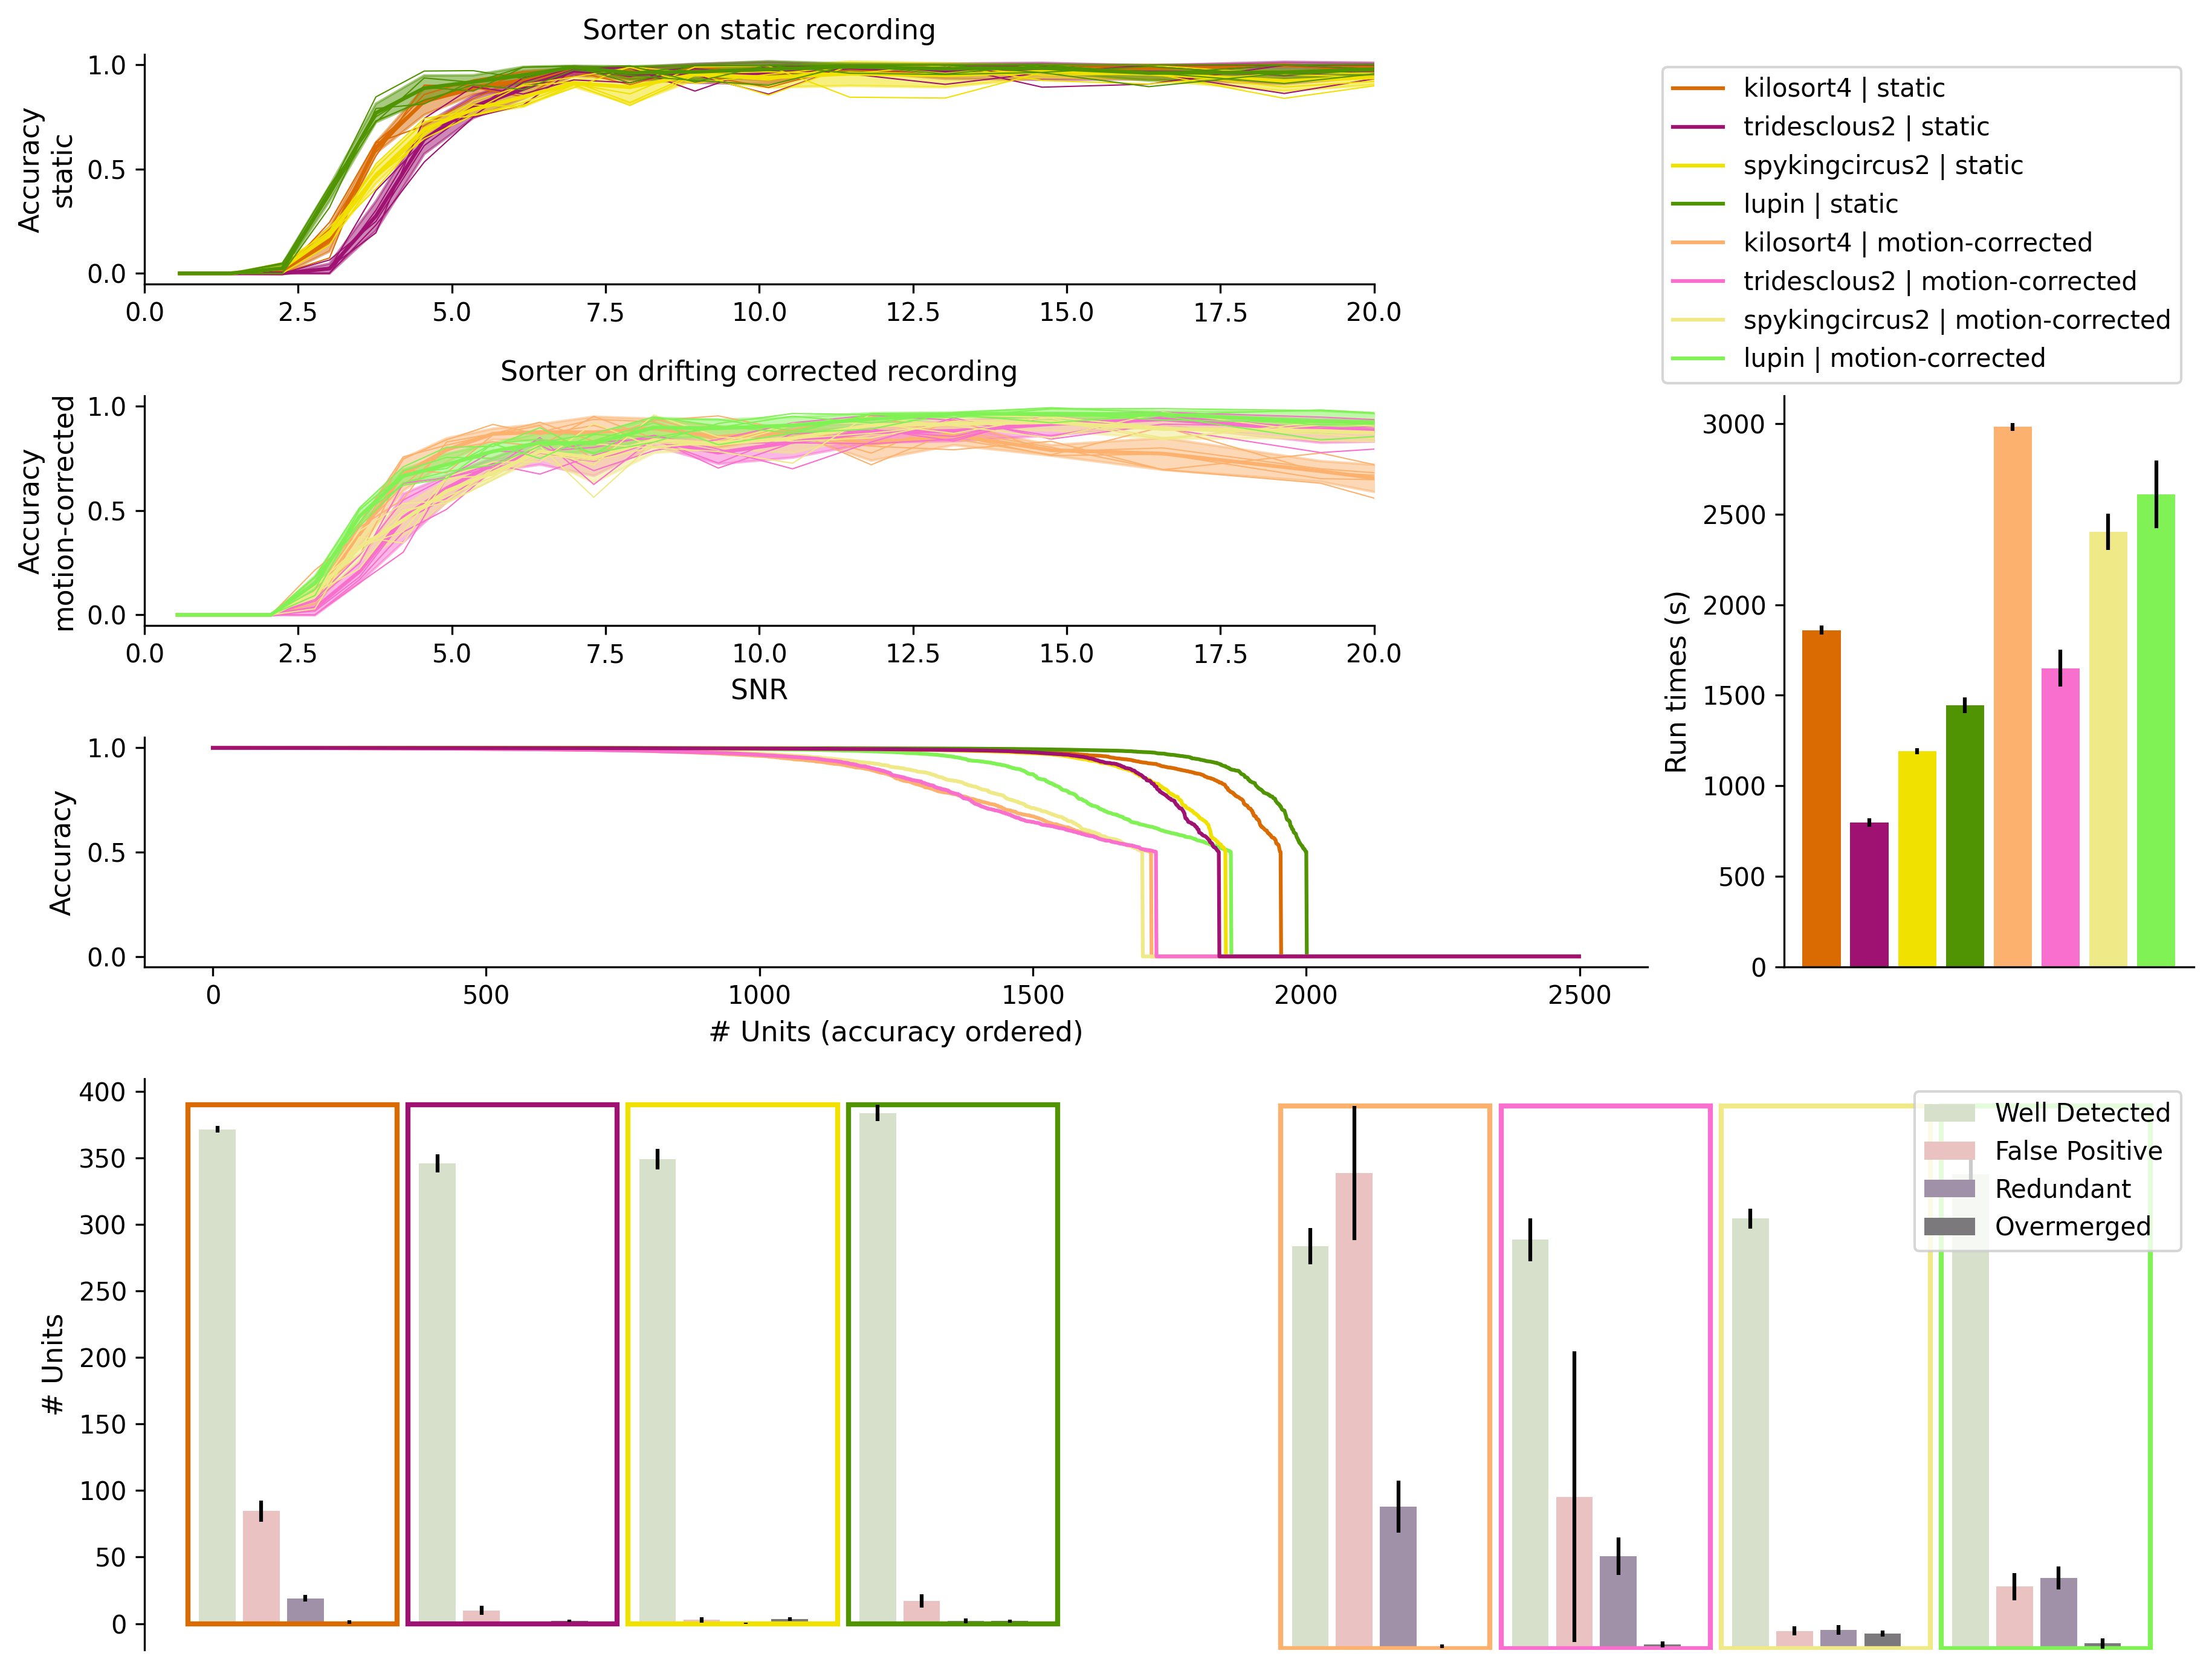

In [7]:
%matplotlib inline
myparams = {
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'legend.fontsize': 10,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
}


import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis, plot_study_legend, plot_performances_ordered
from matplotlib.gridspec import GridSpec


with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(12, 9), dpi=300)
    
    gs = GridSpec(5, 8)
    ax1 = fig.add_subplot(gs[0,:5])
    ax2 = fig.add_subplot(gs[1,:5])
    ax3 = fig.add_subplot(gs[0, 6:8])
    ax4 = fig.add_subplot(gs[1:3, 6:8])
    ax5 = fig.add_subplot(gs[2, :6])

    ax6 = fig.add_subplot(gs[3:5, :4])
    ax7 = fig.add_subplot(gs[3:5, 4:])
    
    
    plot_study_legend(study, case_keys=all_cases,
                      levels_to_group_by=['sorter_name', 'drifting'],
                        ax=ax3)

    _ = study.plot_performances_vs_snr(case_keys=static_cases, performance_names=['accuracy'],
                                       show_scatter=False,
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True,
                                        scatter_size=1,
                                        scatter_alpha=0.25,
                                        # metric_dataset_reference='static',
                                        levels_to_group_by=['sorter_name', 'drifting'],
                                        show_legend=False, axs=[ax1])
    ax1.set_title("Sorter on static recording")
    ax1.set_ylabel('Accuracy\nstatic')

    
    _ = study.plot_performances_vs_snr(case_keys=drifting_cases, performance_names=['accuracy'], 
                                       show_scatter=False,
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        scatter_size=1,
                                        scatter_alpha=0.25,
                                        # metric_dataset_reference='static',
                                        levels_to_group_by=['sorter_name', 'drifting'],
                                        show_legend=False,  axs=[ax2])
    ax2.set_title("Sorter on drifting corrected recording")
    ax2.set_xlabel('SNR')
    ax2.set_ylabel('Accuracy\nmotion-corrected')

    ax1.set_xlim(0, 20)
    ax2.set_xlim(0, 20)
    

    # ax1.sharex(ax2)

    _ = study.plot_run_times(case_keys=all_cases,ax=ax4,
                             levels_to_group_by=['sorter_name', 'drifting'],
                             )
    ax4.set_xticks([])
    ax4.set_xticklabels([])


    study.plot_performances_ordered(case_keys=all_cases, performance_names=['accuracy'],
                                    levels_to_group_by=['sorter_name', 'drifting'],
                                    show_legend=False, axs=[ax5])
    ax5.set_title('')
    ax5.set_xlabel('# Units (accuracy ordered)')
    ax5.set_ylabel('Accuracy')

    for ax in (ax1, ax2, ax5):
        ax.set_yticks([0, 0.5, 1])


    count_colors = dict(
        num_well_detected="#D7E0CB",
        num_false_positive="#EBC2C2",
        num_redundant="#A091A8",
        num_overmerged="#7B797C",
    )

    _ = study.plot_unit_counts(case_keys=static_cases,  ax=ax6,
                               columns=['num_well_detected', 'num_false_positive', 'num_redundant', 'num_overmerged',],
                                levels_to_group_by=['sorter_name', 'drifting'],
                                revert_bad=False,
                                xticks_rotation=0.,
                                colors=count_colors,
                               )
    ax6.get_legend().remove()
    _ = study.plot_unit_counts(case_keys=drifting_cases,  ax=ax7,
                               columns=['num_well_detected', 'num_false_positive', 'num_redundant', 'num_overmerged',],
                                levels_to_group_by=['sorter_name', 'drifting'],
                                revert_bad=False,
                                xticks_rotation=0.,
                                colors=count_colors,
                               )

    for ax in (ax6, ax7):
        ax.set_xticks([])
        ax.set_xticklabels([])
        # ax6.set_xticklabels(list(study.labels_by_levels[('sorter_name', 'drifting')].values()), rotation=0)
        # despine(ax6)
        ax.spines['bottom'].set_visible(False)
    ax7.spines['left'].set_visible(False)
    ax7.set_yticks([])
    ax6.set_ylabel('# Units')

    
    fig.tight_layout(pad=0.0)
    # fig.tight_layout()
    fig.savefig(figure_folder / 'figure_sorters.png')
    fig.savefig(figure_folder / 'figure_sorters.pdf')
